In [1]:
import pandas as pd
import numpy as np
import os
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import shap
import warnings
warnings.filterwarnings('ignore')

# Load data
base = os.path.expanduser("~") + r"\phishguard-ai\datasets\phishing_urls.csv"
df = pd.read_csv(base)

X = df.drop('phishing', axis=1)
y = df['phishing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

C:\Users\tanma\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 70917 | Test: 17730


In [2]:
print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Training complete.")

Training XGBoost...
[0]	validation_0-logloss:0.57319
[50]	validation_0-logloss:0.11462
[100]	validation_0-logloss:0.09851
[150]	validation_0-logloss:0.09063
[200]	validation_0-logloss:0.08581
[250]	validation_0-logloss:0.08286
[299]	validation_0-logloss:0.08080
Training complete.


In [3]:
y_pred = xgb_model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 40)
print("XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Phishing']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n--- COMPARISON ---")
print(f"Random Forest: 97.06% accuracy")
print(f"XGBoost:       {accuracy*100:.2f}% accuracy")

XGBOOST RESULTS
Accuracy:  0.9704  (97.04%)
Precision: 0.9576
Recall:    0.9568
F1 Score:  0.9572

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98     11600
    Phishing       0.96      0.96      0.96      6130

    accuracy                           0.97     17730
   macro avg       0.97      0.97      0.97     17730
weighted avg       0.97      0.97      0.97     17730


Confusion Matrix:
[[11340   260]
 [  265  5865]]

--- COMPARISON ---
Random Forest: 97.06% accuracy
XGBoost:       97.04% accuracy


Computing SHAP values (takes ~30 seconds)...
Done. Top features by SHAP importance:


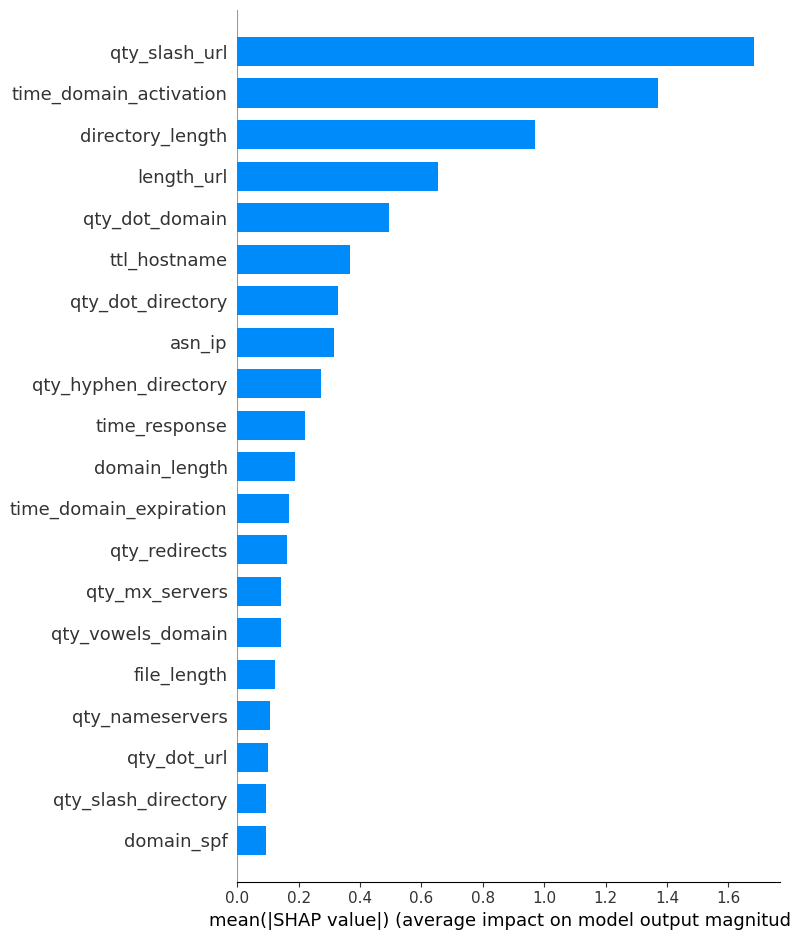

Plot saved.


In [4]:
# SHAP explains individual predictions
# "Why did the model flag THIS specific URL?"
print("Computing SHAP values (takes ~30 seconds)...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:500])  # first 500 rows

print("Done. Top features by SHAP importance:")
shap.summary_plot(shap_values, X_test[:500], plot_type="bar", show=False)

import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig(os.path.expanduser("~") + r"\phishguard-ai\models\shap_importance.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [5]:
# Pick one phishing URL from the test set and explain it
phishing_indices = y_test[y_test == 1].index
sample_idx = phishing_indices[0]
sample = X_test.loc[[sample_idx]]

prediction = xgb_model.predict(sample)[0]
probability = xgb_model.predict_proba(sample)[0]

print(f"Prediction: {'PHISHING' if prediction == 1 else 'LEGITIMATE'}")
print(f"Confidence: {max(probability)*100:.1f}%")
print(f"\nTop 10 features for this URL:")

sample_shap = explainer.shap_values(sample)[0]
feature_shap = pd.DataFrame({
    'feature': X.columns,
    'value': sample.values[0],
    'shap': sample_shap
}).reindex(pd.Series(abs(sample_shap)).sort_values(ascending=False).index)

print(feature_shap.head(10).to_string(index=False))

Prediction: PHISHING
Confidence: 96.6%

Top 10 features for this URL:
               feature   value      shap
         qty_slash_url     3.0  1.390381
      directory_length    25.0  1.199098
                asn_ip 20013.0  0.677994
        qty_dot_domain     2.0 -0.381684
            domain_spf     1.0  0.360148
  qty_hyphen_directory     0.0  0.352777
            length_url    40.0  0.248842
          ttl_hostname   407.0 -0.217803
     qty_dot_directory     1.0  0.180746
time_domain_activation  3230.0 -0.166034
